In [1]:
"""Test OneLayer scattering model"""
import sys
sys.path.append('../../')
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sci_const
from mores.model.OneLayer import OneLayer
from mores.utils.postprocessing import Mueller2sigma0VH

In [3]:
f = 1.0e9
epsr0 = 1.0
epsr1 = 3.0
epsr2 = 6.0
thickness = 5.0
kdel1 = 0.3
kcor1 = 3.0
kdel2 = 0.3
kcor2 = 3.0

Lambda = sci_const.speed_of_light / f
k = 2*np.pi / Lambda
surface_para = {'model': 'RoughSurface', 'delta': kdel1/k, 'corr_len': kcor1/k}
subsurface_para = {'model': 'RoughSurface', 'delta': kdel2/k, 'corr_len': kcor2/k}
inclusion_para = {'ks': 0.3, 'ka':0.4}

In [4]:
mymodel = OneLayer(f=f, epsr0=epsr0, epsr1=epsr1, epsr2=epsr2, thickness=thickness, 
                 surface_para=surface_para, subsurface_para=subsurface_para, inclusion_para=inclusion_para)

e:\zhaofei\exps\project\lunar_scattering\lunar_regolith_scattering\mores\mores\test\../..\mores\core\VRT.py:53: UserWarning: The ssa (0.4285714285714286) is too high, the first-order iterative VRT solver may obtain inaccurate results.
  warnings.warn("The ssa ({}) is too high, the first-order iterative VRT solver may obtain inaccurate results.".format(ssa))


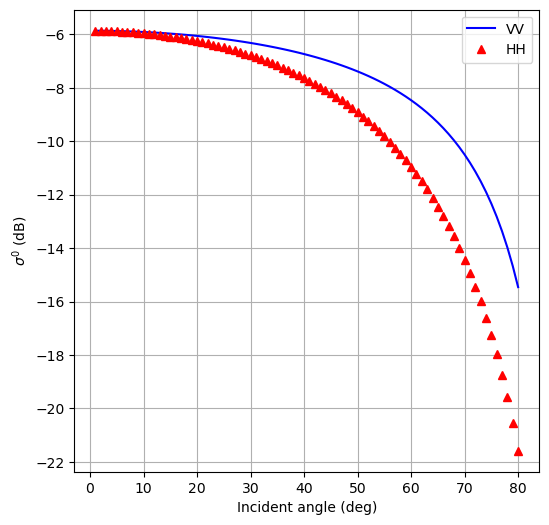

In [6]:
# run model and plot
theta_is = np.linspace(1., 80., 80)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
sigma0_HVs = np.zeros(Num)
sig_tmp = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    theta_s = theta_i
    Mue_sur = mymodel.Mue_surface((theta_s, 180, theta_i, 0))
    Mue_vol = mymodel.Mue_volume((theta_s, 180, theta_i, 0))
    Mue_sub = mymodel.Mue_subsurface((theta_s, 180, theta_i, 0))
    Mue_sub_vol = mymodel.Mue_subsurface_volume((theta_s, 180, theta_i, 0))
    Mue_total = Mue_sur + Mue_vol + Mue_sub + Mue_sub_vol
    # Mue = mymodel.Mue_volume((theta_i, 180, theta_i, 0)) + vrt.Mue_surface((theta_i, 180, theta_i, 0))
    Mue = Mue_vol
    # Mue = np.diag([1]*4)
    sigma_VV, _, sigma_HV, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    # sigma0_VVs[i] = 4*np.pi*Mue[0, 0]
    sigma0_HHs[i] = sigma_HH
    sigma0_HVs[i] = sigma_HV

    # M = subsurface.Mue_noncoh_R((theta_i, 180, theta_i, 0))
    # sig_tmp[i] = 10*np.log10(4*np.pi*M[0, 0])

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
# sigma0_HV_dB = 10*np.log10(sigma0_HVs)

plt.figure(figsize=(6, 6))
# plt.plot(theta_is, sigma0_VV_dB+10*np.log10(np.cos(np.deg2rad(theta_is))), 'b-', label='VV')
# plt.plot(theta_is, sigma0_HH_dB+10*np.log10(np.cos(np.deg2rad(theta_is))), 'r^', label='HH')
plt.plot(theta_is, sigma0_VV_dB, 'b-', label='VV')
plt.plot(theta_is, sigma0_HH_dB, 'r^', label='HH')
# plt.plot(theta_is, sig_tmp, 'g--', label='tmp')
# plt.ylim(-20, -6)
# plt.yticks(np.arange(-20, 6, 1))
# plt.ylim(-1.5, 0)
# plt.yticks(np.arange(-1.5, 0, 0.5))
plt.xlabel('Incident angle (deg)')
plt.ylabel(r'$\sigma^0$ (dB)')
plt.legend()
plt.grid()
plt.show()
